Dataset Preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

Standardized Data Preview:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Principal Components:


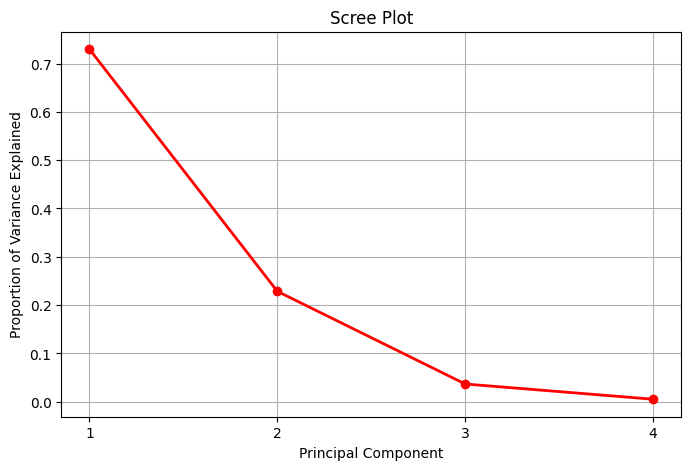


Explained Variance Ratio per component:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052


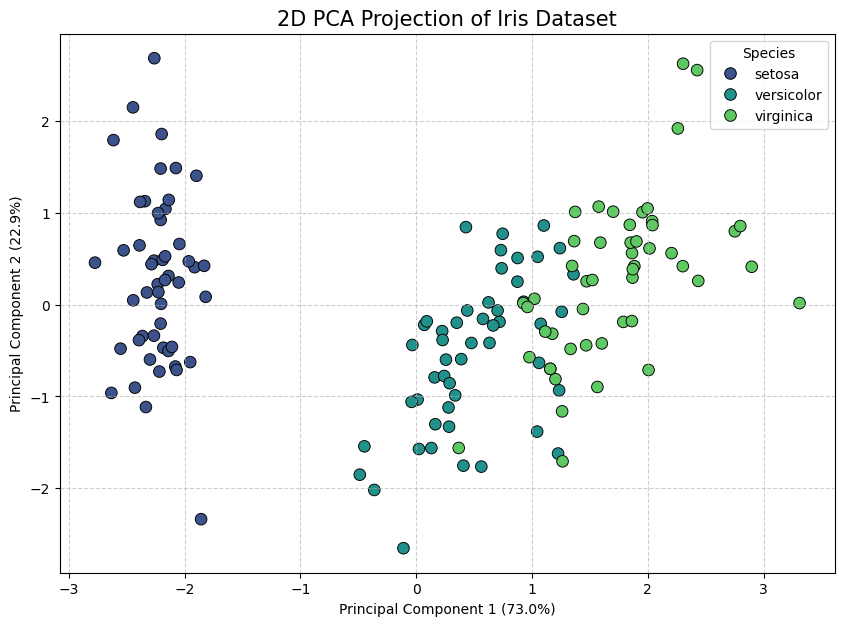

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris()

df = pd.DataFrame(data = iris.data, columns = iris.feature_names)

df['target'] = iris.target

print("Dataset Preview:")
print(df.head())
print(df.columns)

x = df.drop("target", axis = 1)
y = df["target"]

scalar = StandardScaler()

X_scaled = scalar.fit_transform(x)

print("\nStandardized Data Preview:")
print(X_scaled[:5])

pca = PCA(n_components=None)

X_pca = pca.fit_transform(X_scaled)

pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(data = X_pca, columns = pca_columns)

print("\nPrincipal Components:")
print(df_pca.head())

plt.figure(figsize=(8, 5))
plt.plot(range(1, 5), pca.explained_variance_ratio_, 'ro-', linewidth=2)

plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, 5)) # Ensure x-axis shows 1, 2, 3, 4
plt.grid(True)
plt.show()

print("\nExplained Variance Ratio per component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=iris.target_names[y], # Use the actual names (Setosa, etc.)
    palette='viridis',
    s=70,
    edgecolor='k'
)

plt.title('2D PCA Projection of Iris Dataset', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#import plotly.express as px

# 1. Perform PCA specifically for 3 components
#pca_3d = PCA(n_components=3)
#X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2. Create a DataFrame for Plotly
#df_3d = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
#df_3d['Species'] = iris.target_names[y]

# 3. Generate the Interactive Plot
#fig = px.scatter_3d(
#    df_3d, x='PC1', y='PC2', z='PC3',
#    color='Species',
#    title='3D Interactive PCA (Iris Dataset)',
#    labels={'PC1': 'PC 1', 'PC2': 'PC 2', 'PC3': 'PC 3'},
#    opacity=0.8
#)

# Change this line in your code:
# Change to this:
#fig.show(renderer="png")